# 0. Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# 1. Data Loading

In [2]:
wine_data = load_wine()
X, y = wine_data.data, wine_data.target
feature_names = wine_data.feature_names
target_names = wine_data.target_names

# Create DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{pd.Series(y).value_counts().sort_index()}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

Dataset Information:
Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution:
0    59
1    71
2    48
Name: count, dtype: int64

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18     

Dataset Statistics:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.57235

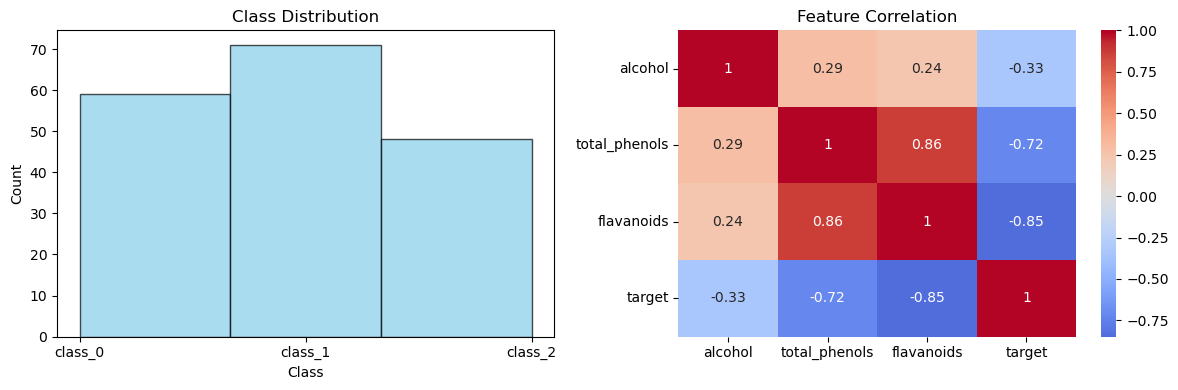

In [3]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())

# Visualize class distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=3, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(range(3), target_names)

# Feature correlation heatmap (subset of features for readability)
plt.subplot(1, 2, 2)
corr_features = df[['alcohol', 'total_phenols', 'flavanoids', 'target']].corr()
sns.heatmap(corr_features, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation')

plt.tight_layout()
plt.show()

In [4]:
# Split features and target
X = df.drop('target', axis=1).values
y = df['target'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features scaled: ✅")

Data Preprocessing Complete:
Training set: (124, 13)
Test set: (54, 13)
Features scaled: ✅


# 1.5 Data Loading 2 (Run this after implementation is done! Refer to the 5.Questions)

In [ ]:
cancer_data = load_breast_cancer()
X, y = cancer_data.data, cancer_data.target
feature_names = cancer_data.feature_names
target_names = cancer_data.target_names  # ['malignant' 'benign']

# Create DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{pd.Series(y).value_counts().sort_index()}")

In [ ]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())

# Visualize class distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=2, alpha=0.7, color='skyblue', edgecolor='black')  # bins=2 for binary classification
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(range(2), target_names)  # range(2) for binary classification

# Feature correlation heatmap (subset of features for readability)
plt.subplot(1, 2, 2)
# Select some meaningful features from breast cancer dataset
corr_features = df[['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'target']].corr()
sns.heatmap(corr_features, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation')

plt.tight_layout()
plt.show()

In [ ]:
# Split features and target
X = df.drop('target', axis=1).values
y = df['target'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features scaled: ✅")

# 2. Implementing Naive Bayes Classifier



In [5]:
class NaiveBayesFromScratch:
    def __init__(self):
        self.classes = None
        self.class_priors = {}
        self.feature_params = {}

    def fit(self, X, y):
        """Train Gaussian Naive Bayes classifier"""
        self.classes = np.unique(y)
        n_samples = len(y)

        for cls in self.classes:
            # Calculate class prior P(y=cls)
            cls_samples = (y == cls)
            self.class_priors[cls] = np.sum(cls_samples) / n_samples

            # Calculate feature parameters for this class
            X_cls = X[cls_samples]
            self.feature_params[cls] = {
                'mean': np.mean(X_cls, axis=0),
                'var': np.var(X_cls, axis=0) + 1e-9  # Add small value to prevent division by zero
            }

    def _gaussian_probability(self, x, mean, var):
        # TODO: Implement the Gaussian PDF formula
        # 1e9 -> Add small value to prevent division by zero
        exponential = np.exp(-((x - mean) ** 2) / (2 * var + 1e-9))
        return 1.0 / np.sqrt(2.0 * np.pi * var + 1e-9) * exponential

    def predict_proba(self, X):
        """Predict class probabilities"""
        # TODO: For each class, calculate P(class) * P(features | class)
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        posteriors = np.zeros((n_samples, n_classes))  # posteriors initialization
        
        for idx, cls in enumerate(self.classes):
            # P(class)
            prior = np.log(self.class_priors[cls])
            
            # P(features | class)
            mean = self.feature_params[cls]['mean']
            var = self.feature_params[cls]['var']
            
            # Log Likelihood Sum
            likelihood = np.sum(np.log(self._gaussian_probability(X, mean, var) + 1e-9), axis=1)
            
            # Log Posterior
            posteriors[:, idx] = prior + likelihood
        
        # TODO: Normalize to get proper probabilities
        # Convert log space to normal space
        posteriors = posteriors - np.max(posteriors, axis=1, keepdims=True)
        posteriors = np.exp(posteriors)
        # normalize to probabilities sum = 1
        posteriors = posteriors / np.sum(posteriors, axis=1, keepdims=True)
        
        return posteriors

    def predict(self, X):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]

In [6]:
# Train your own implementation
nb_scratch = NaiveBayesFromScratch()
nb_scratch.fit(X_train_scaled, y_train)

y_pred_scratch = nb_scratch.predict(X_test_scaled)
y_prob_scratch = nb_scratch.predict_proba(X_test_scaled)

print("✅ Naive Bayes from scratch implemented and trained!")

✅ Naive Bayes from scratch implemented and trained!


In [7]:
# Compare with sklearn implementation
nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = nb_sklearn.predict(X_test_scaled)

# Calculate accuracy for both implementations
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

accuracy_scratch = calculate_accuracy(y_test, y_pred_scratch)
accuracy_sklearn = calculate_accuracy(y_test, y_pred_sklearn)

print("Naive Bayes Verification:")
print(f"Your implementation accuracy: {accuracy_scratch:.4f}")
print(f"Sklearn implementation accuracy: {accuracy_sklearn:.4f}")
print(f"Difference: {abs(accuracy_scratch - accuracy_sklearn):.4f}")

# Check if predictions are similar (allowing for small numerical differences)
prediction_similarity = np.mean(y_pred_scratch == y_pred_sklearn)
print(f"Prediction agreement: {prediction_similarity:.4f}")

if prediction_similarity > 0.95:
    print("✅ Implementation verified!")
else:
    print("⚠️ Check implementation - significant differences detected")

Naive Bayes Verification:
Your implementation accuracy: 1.0000
Sklearn implementation accuracy: 1.0000
Difference: 0.0000
Prediction agreement: 1.0000
✅ Implementation verified!


# 3. Implementing KNN


In [8]:
class KNNFromScratch:
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y

    def _calculate_distance(self, x1, x2):
        """Calculate distance between two points"""
        if self.distance_metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.distance_metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_metric == 'minkowski':
            p = 3  # Minkowski parameter
            return (np.sum(np.abs(x1 - x2) ** p)) ** (1/p)
        else:
            raise ValueError("Unsupported distance metric")

    def predict(self, X):
        """Predict class labels for test data"""
        predictions = []
        for test_point in X:
            # TODO: Calculate distances to all training points
            distances = []
            for i, train_point in enumerate(self.X_train):
                dist = self._calculate_distance(test_point, train_point)
                distances.append((dist, self.y_train[i]))  # save (distance, label) pair
            
            # TODO: Sort distances and get k nearest neighbors
            distances.sort(key=lambda x: x[0])  # Sort distances
            kNN = [label for distance, label in distances[:self.k]]  # KNN extraction
            
            # TODO: Return majority class among k neighbors
            majority = np.bincount(kNN).argmax()  # Majority vote
            predictions.append(majority)

        return np.array(predictions)

    def predict_proba(self, X):
        """Predict class probabilities"""
        probabilities = []
        classes = np.unique(self.y_train)

        for test_point in X:
            # Calculate distances to all training points
            distances = []
            for i, train_point in enumerate(self.X_train):
                dist = self._calculate_distance(test_point, train_point)
                distances.append((dist, self.y_train[i]))

            # Sort by distance and get k nearest neighbors
            distances.sort()
            k_nearest = distances[:self.k]
            k_labels = [label for _, label in k_nearest]

            # Calculate probability for each class
            class_probs = []
            for cls in classes:
                prob = k_labels.count(cls) / self.k
                class_probs.append(prob)

            probabilities.append(class_probs)

        return np.array(probabilities)

In [9]:
# Train KNN with different distance metrics
knn_models = {}
distance_metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in distance_metrics:
    knn = KNNFromScratch(k=5, distance_metric=metric)
    knn.fit(X_train_scaled, y_train)
    knn_models[metric] = knn

print("✅ KNN implementations with different distance metrics trained!")

✅ KNN implementations with different distance metrics trained!


In [10]:
def cross_validation_knn(X, y, k_values, cv_folds=5):
    """Perform cross-validation to find best k"""
    scores = {}

    for k in k_values:
        fold_scores = []

        # Simple CV implementation
        fold_size = len(X) // cv_folds

        for fold in range(cv_folds):
            # Create train/validation split for this fold
            start_idx = fold * fold_size
            end_idx = start_idx + fold_size

            X_val_fold = X[start_idx:end_idx]
            y_val_fold = y[start_idx:end_idx]

            X_train_fold = np.concatenate([X[:start_idx], X[end_idx:]])
            y_train_fold = np.concatenate([y[:start_idx], y[end_idx:]])

            # Train and evaluate
            knn = KNNFromScratch(k=k)
            knn.fit(X_train_fold, y_train_fold)
            y_pred_fold = knn.predict(X_val_fold)

            accuracy = calculate_accuracy(y_val_fold, y_pred_fold)
            fold_scores.append(accuracy)

        scores[k] = np.mean(fold_scores)

    return scores

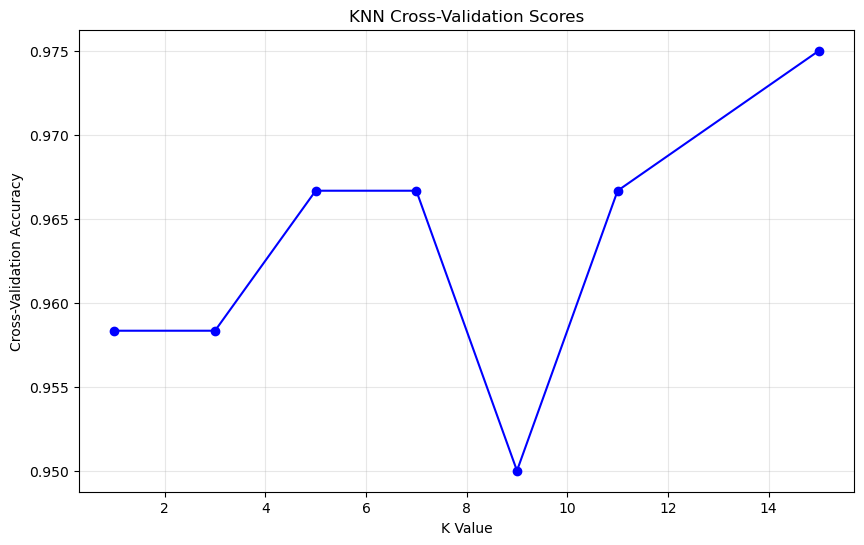

Best K value: 15 (CV accuracy: 0.9750)


In [11]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 11, 15]
cv_scores = cross_validation_knn(X_train_scaled, y_train, k_values)

# Plot CV scores
plt.figure(figsize=(10, 6))
plt.plot(list(cv_scores.keys()), list(cv_scores.values()), 'bo-')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Scores')
plt.grid(True, alpha=0.3)
plt.show()

best_k = max(cv_scores, key=cv_scores.get)
print(f"Best K value: {best_k} (CV accuracy: {cv_scores[best_k]:.4f})")

In [12]:
# Train your best KNN and sklearn KNN
knn_scratch = KNNFromScratch(k=best_k)
knn_scratch.fit(X_train_scaled, y_train)
y_pred_knn_scratch = knn_scratch.predict(X_test_scaled)

knn_sklearn = KNeighborsClassifier(n_neighbors=best_k)
knn_sklearn.fit(X_train_scaled, y_train)
y_pred_knn_sklearn = knn_sklearn.predict(X_test_scaled)

# Compare accuracies
accuracy_knn_scratch = calculate_accuracy(y_test, y_pred_knn_scratch)
accuracy_knn_sklearn = calculate_accuracy(y_test, y_pred_knn_sklearn)

print("KNN Verification:")
print(f"Your implementation accuracy: {accuracy_knn_scratch:.4f}")
print(f"Sklearn implementation accuracy: {accuracy_knn_sklearn:.4f}")
print(f"Difference: {abs(accuracy_knn_scratch - accuracy_knn_sklearn):.4f}")

# Check prediction agreement
knn_agreement = np.mean(y_pred_knn_scratch == y_pred_knn_sklearn)
print(f"Prediction agreement: {knn_agreement:.4f}")

if knn_agreement > 0.95:
    print("✅ KNN implementation verified!")
else:
    print("⚠️ Check implementation - significant differences detected")


KNN Verification:
Your implementation accuracy: 0.9815
Sklearn implementation accuracy: 0.9815
Difference: 0.0000
Prediction agreement: 1.0000
✅ KNN implementation verified!


# 4. Implementing Evaluation Metrics

In [13]:
class ClassificationMetrics:
    def __init__(self, y_true, y_pred, y_prob=None):
        self.y_true = y_true
        self.y_pred = y_pred
        self.y_prob = y_prob
        self.classes = np.unique(y_true)

    def confusion_matrix(self):
        """Calculate confusion matrix"""
        n_classes = len(self.classes)
        cm = np.zeros((n_classes, n_classes), dtype=int)

        for i, true_class in enumerate(self.classes):
            for j, pred_class in enumerate(self.classes):
                cm[i, j] = np.sum((self.y_true == true_class) & (self.y_pred == pred_class))

        return cm

    def accuracy(self):
        """Calculate accuracy"""
        return np.mean(self.y_true == self.y_pred)

    def precision_recall_f1(self):
        """Calculate precision, recall, and F1 for each class"""
        cm = self.confusion_matrix()
        # TODO: For each class i, calculate:
        
        n_classes = len(self.classes)
        precision = np.zeros(n_classes)
        recall = np.zeros(n_classes)
        f1 = np.zeros(n_classes)
        
        for i in range(n_classes):
            # True Positives (TP)
            TP = cm[i, i]
            
            # False Positives (FP)
            FP = np.sum(cm[:, i]) - TP
            
            # False Negatives (FN)
            FN = np.sum(cm[i, :]) - TP
            
            # TODO: precision[i] = TP[i] / (TP[i] + FP[i])
            if (TP + FP) > 0:
                precision[i] = TP / (TP + FP)
            else:
                precision[i] = 0
            
            # TODO: recall[i] = TP[i] / (TP[i] + FN[i])
            if (TP + FN) > 0:
                recall[i] = TP / (TP + FN)
            else:
                recall[i] = 0
            
            # TODO: f1[i] = 2 * precision * recall / (precision + recall)
            if (precision[i] + recall[i]) > 0:
                f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i])
            else:
                f1[i] = 0

        return precision, recall, f1

    def macro_metrics(self):
        """Calculate macro-averaged metrics"""
        precision, recall, f1 = self.precision_recall_f1()
        return {
            'macro_precision': np.mean(precision),
            'macro_recall': np.mean(recall),
            'macro_f1': np.mean(f1)
        }

    def roc_auc_multiclass(self):
        """Calculate ROC AUC for multiclass (one-vs-rest)"""
        if self.y_prob is None:
            return None

        aucs = []
        for i, cls in enumerate(self.classes):
            # Create binary problem: class i vs rest
            y_binary = (self.y_true == cls).astype(int)
            y_prob_binary = self.y_prob[:, i]

            # Calculate ROC curve
            fpr, tpr, _ = self._roc_curve_binary(y_binary, y_prob_binary)
            auc_score = self._auc(fpr, tpr)
            aucs.append(auc_score)

        return aucs

    def _roc_curve_binary(self, y_true, y_scores):
        """Calculate ROC curve for binary classification"""
        # Sort by score
        sorted_indices = np.argsort(y_scores)[::-1]
        y_true_sorted = y_true[sorted_indices]
        y_scores_sorted = y_scores[sorted_indices]

        # Calculate TPR and FPR
        tpr = []
        fpr = []

        thresholds = np.unique(y_scores_sorted)
        thresholds = np.append(thresholds, thresholds[-1] - 1)

        for threshold in thresholds:
            y_pred_binary = (y_scores >= threshold).astype(int)

            tp = np.sum((y_true == 1) & (y_pred_binary == 1))
            fp = np.sum((y_true == 0) & (y_pred_binary == 1))
            tn = np.sum((y_true == 0) & (y_pred_binary == 0))
            fn = np.sum((y_true == 1) & (y_pred_binary == 0))

            tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0

            tpr.append(tpr_val)
            fpr.append(fpr_val)

        return np.array(fpr), np.array(tpr), thresholds

    def _auc(self, fpr, tpr):
        """Calculate AUC using trapezoidal rule"""
        return np.trapz(tpr, fpr)

In [14]:
# Test your metrics implementation
nb_prob_scratch = nb_scratch.predict_proba(X_test_scaled)
metrics_nb = ClassificationMetrics(y_test, y_pred_scratch, nb_prob_scratch)

print("Classification Metrics for Naive Bayes:")
print(f"Accuracy: {metrics_nb.accuracy():.4f}")

precision, recall, f1 = metrics_nb.precision_recall_f1()
for i, cls_name in enumerate(target_names):
    print(f"{cls_name} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f}")

macro_metrics = metrics_nb.macro_metrics()
print(f"Macro-averaged - Precision: {macro_metrics['macro_precision']:.4f}, "
      f"Recall: {macro_metrics['macro_recall']:.4f}, F1: {macro_metrics['macro_f1']:.4f}")

Classification Metrics for Naive Bayes:
Accuracy: 1.0000
class_0 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
class_1 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
class_2 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Macro-averaged - Precision: 1.0000, Recall: 1.0000, F1: 1.0000


In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix as sklearn_cm

# Compare your metrics with sklearn
sklearn_accuracy = accuracy_score(y_test, y_pred_scratch)
sklearn_precision, sklearn_recall, sklearn_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_scratch, average=None
)
sklearn_macro_precision, sklearn_macro_recall, sklearn_macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_scratch, average='macro'
)

print("Metrics Verification:")
print(f"Accuracy - Your: {metrics_nb.accuracy():.4f}, Sklearn: {sklearn_accuracy:.4f}")
print(f"Macro Precision - Your: {macro_metrics['macro_precision']:.4f}, Sklearn: {sklearn_macro_precision:.4f}")
print(f"Macro Recall - Your: {macro_metrics['macro_recall']:.4f}, Sklearn: {sklearn_macro_recall:.4f}")
print(f"Macro F1 - Your: {macro_metrics['macro_f1']:.4f}, Sklearn: {sklearn_macro_f1:.4f}")

# Check confusion matrix
your_cm = metrics_nb.confusion_matrix()
sklearn_confusion = sklearn_cm(y_test, y_pred_scratch)

print("\nConfusion Matrix Comparison:")
print("Your implementation:")
print(your_cm)
print("Sklearn:")
print(sklearn_confusion)

cm_match = np.array_equal(your_cm, sklearn_confusion)
print(f"Confusion matrices match: {cm_match}")

if cm_match:
    print("✅ Metrics implementation verified!")

Metrics Verification:
Accuracy - Your: 1.0000, Sklearn: 1.0000
Macro Precision - Your: 1.0000, Sklearn: 1.0000
Macro Recall - Your: 1.0000, Sklearn: 1.0000
Macro F1 - Your: 1.0000, Sklearn: 1.0000

Confusion Matrix Comparison:
Your implementation:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]
Sklearn:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]
Confusion matrices match: True
✅ Metrics implementation verified!


In [16]:
# Train both models and get predictions
models = {
    'Naive Bayes (Scratch)': (nb_scratch, y_pred_scratch, nb_prob_scratch),
    'KNN (Scratch)': (knn_scratch, y_pred_knn_scratch, knn_scratch.predict_proba(X_test_scaled))
}

# Create comparison table
comparison_results = []

for model_name, (model, y_pred, y_prob) in models.items():
    metrics = ClassificationMetrics(y_test, y_pred, y_prob)

    precision, recall, f1 = metrics.precision_recall_f1()
    macro_metrics = metrics.macro_metrics()

    comparison_results.append({
        'Model': model_name,
        'Accuracy': metrics.accuracy(),
        'Macro Precision': macro_metrics['macro_precision'],
        'Macro Recall': macro_metrics['macro_recall'],
        'Macro F1': macro_metrics['macro_f1']
    })

# Display results
comparison_df = pd.DataFrame(comparison_results)
print("Model Comparison Results:")
print(comparison_df.round(4))

Model Comparison Results:
                   Model  Accuracy  Macro Precision  Macro Recall  Macro F1
0  Naive Bayes (Scratch)    1.0000           1.0000        1.0000    1.0000
1          KNN (Scratch)    0.9815           0.9792        0.9841    0.9811


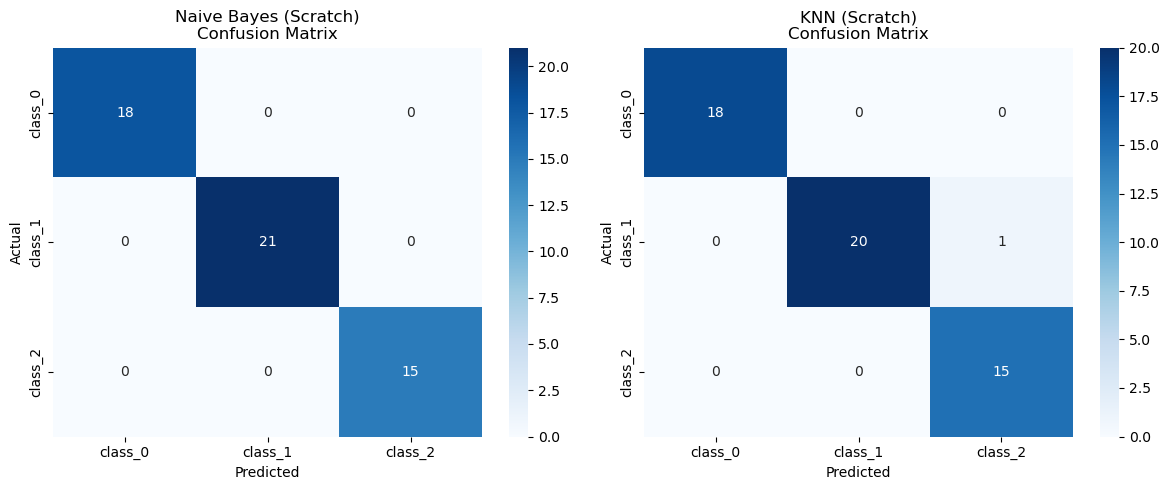

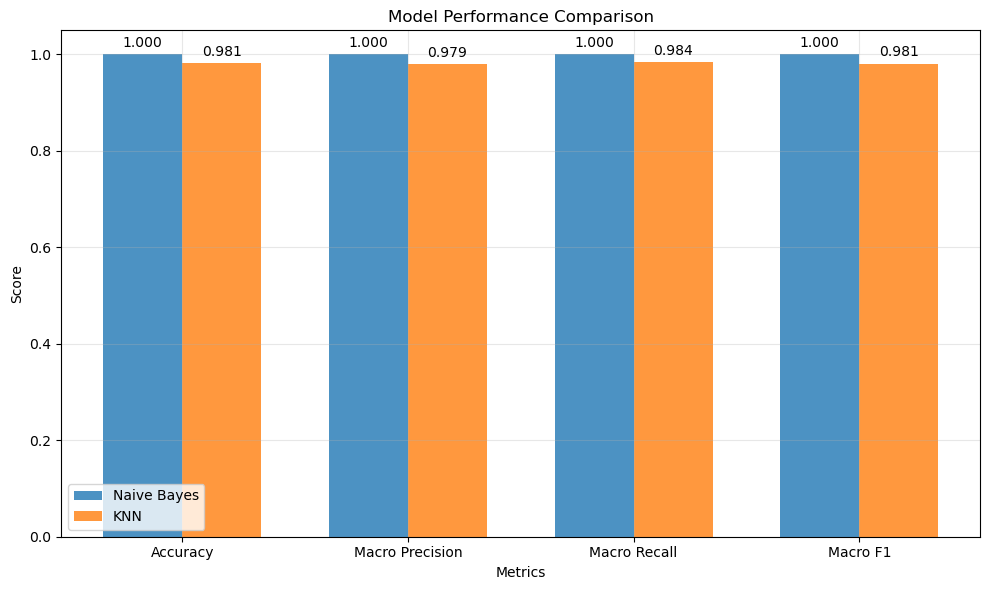

In [17]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (model_name, (model, y_pred, y_prob)) in enumerate(models.items()):
    metrics = ClassificationMetrics(y_test, y_pred, y_prob)
    cm = metrics.confusion_matrix()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Performance comparison bar plot
metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

nb_scores = [comparison_results[0][metric] for metric in metrics_to_plot]
knn_scores = [comparison_results[1][metric] for metric in metrics_to_plot]

rects1 = ax.bar(x - width/2, nb_scores, width, label='Naive Bayes', alpha=0.8)
rects2 = ax.bar(x + width/2, knn_scores, width, label='KNN', alpha=0.8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# 5. Questions

1. Briefly describe this dataset, focusing on their characteristics.
2. Compare the performance of Naive Bayes vs KNN on this dataset. Which performs better and why?
3. How do the assumptions of Naive Bayes hold for this dataset?
4. How does the choice of distance metric affect KNN performance?
5. Change the dataloader to the breast cancer dataset, by running **1.5 Data Loading 2**. Describe how each model's performance changes. From the perspective of dataset, answer why such changes are observed.